In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from seaborn import kdeplot
from ot.lp import wasserstein_1d as wd

plt.style.use("ggplot")

In [2]:
mcmc_4 = np.load("mcmc_results_4/avg_wd_mcmc.npy")
mcmc_0 = np.load("mcmc_results_0/avg_wd_mcmc.npy")
mcmc_1 = np.load("mcmc_results_1/avg_wd_mcmc.npy")
sample_no_list = np.load("sample_no_list.npy").tolist()

In [3]:
no_trials = 10

df_sde = pd.read_csv("sde_4.csv")
sde_mean_4 = df_sde.iloc[:, 1].to_numpy()

df_sde = pd.read_csv("sde_0.csv")
sde_mean_0 = df_sde.iloc[:, 1].to_numpy()

df_sde = pd.read_csv("sde_1.csv")
sde_mean_1 = df_sde.iloc[:, 1].to_numpy()

In [4]:
ode_array_4 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_4[i, :] = np.load(f"converge_results_4/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean_4 = np.mean(ode_array_4, axis=0)

ode_array_0 = np.zeros((no_trials, 23))
for i in range(no_trials):
    ode_array_0[i, :] = np.load(f"converge_results_0/run_{i:02d}/nn_conv_wd_{i}.npy")
ode_mean_0 = np.mean(ode_array_0, axis=0)

# ode_array_1 = np.zeros((no_trials, 23))
# for i in range(no_trials):
#     ode_array_1[i, :] = np.load(f"converge_results_banana/run_{i:02d}/nn_conv_wd_{i}.npy")
# ode_mean_1 = np.mean(ode_array_1, axis=0)
df_ode = pd.read_csv("ode_1.csv")
ode_mean_1 = df_ode.iloc[:, 1].to_numpy()

In [24]:
# sde_array_4 = np.zeros((no_trials, 23))
# for i in range(no_trials):
#     sde_array_4[i, :] = np.load(f"converge_results_4_sde/run_{i:02d}/nn_conv_wd_{i}.npy")
# sde_mean_4 = np.mean(sde_array_4, axis=0)

sde_array_0 = np.zeros((no_trials, 23))
for i in range(no_trials):
    sde_array_0[i, :] = np.load(f"converge_results_0_sde/run_{i:02d}/nn_conv_wd_{i}.npy")
sde_mean_0 = np.mean(sde_array_0, axis=0)

sde_array_1 = np.zeros((no_trials, 23))
for i in range(no_trials):
    sde_array_1[i, :] = np.load(f"converge_results_1_sde/run_{i:02d}/nn_conv_wd_{i}.npy")
sde_mean_1 = np.mean(sde_array_1, axis=0)

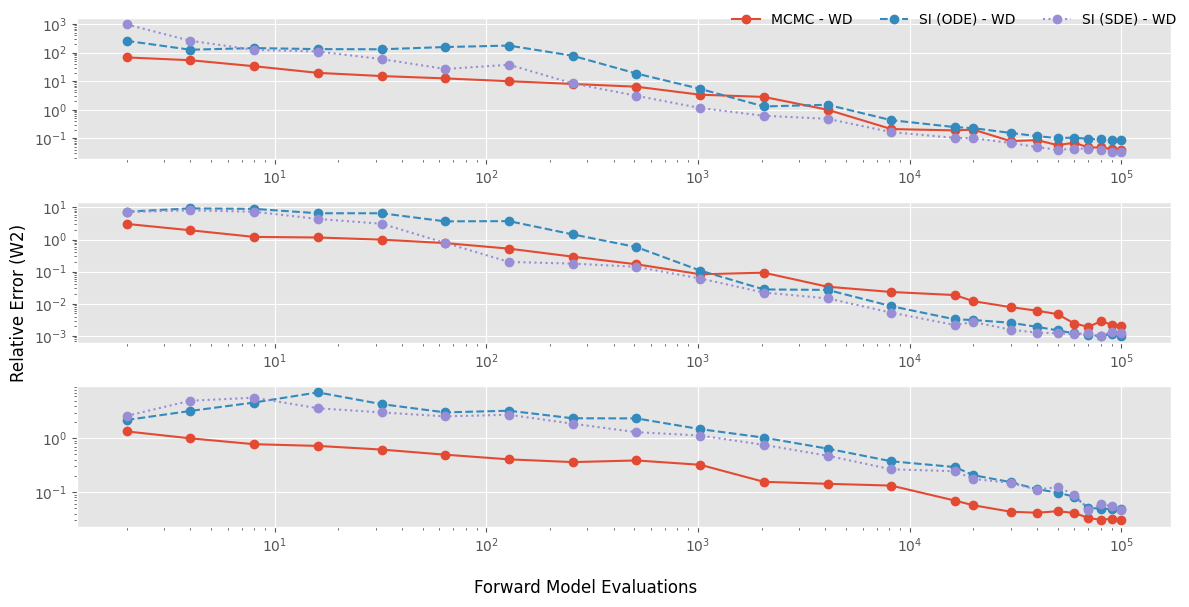

In [5]:
fig, ax = plt.subplots(3, 1, figsize=(12,6))

ax[0].plot(sample_no_list, mcmc_0, marker="o", label="MCMC - WD")
ax[0].plot(sample_no_list, ode_mean_0, marker="o", linestyle="dashed", label="SI (ODE) - WD")
ax[0].plot(sample_no_list, sde_mean_0, marker="o", linestyle="dotted", label="SI (SDE) - WD")
ax[0].set_xscale("log")
ax[0].set_yscale("log")

ax[1].plot(sample_no_list, mcmc_1, marker="o")
ax[1].plot(sample_no_list, ode_mean_1, marker="o", linestyle="dashed")
ax[1].plot(sample_no_list, sde_mean_1, marker="o", linestyle="dotted")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

ax[2].plot(sample_no_list, mcmc_4, marker="o")
ax[2].plot(sample_no_list, ode_mean_4, marker="o", linestyle="dashed")
ax[2].plot(sample_no_list, sde_mean_4, marker="o", linestyle="dotted")
ax[2].set_xscale("log")
ax[2].set_yscale("log")

fig.supylabel("Relative Error (W2)")
fig.supxlabel("Forward Model Evaluations")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    ncol=3,
    frameon=False
)

plt.tight_layout()

In [213]:
mcmc_4

array([1.34054214, 0.99634806, 0.77613215, 0.7208642 , 0.61674348,
       0.49511557, 0.40600092, 0.36080973, 0.3871938 , 0.32184755,
       0.15544863, 0.14260236, 0.13217117, 0.06951819, 0.05700663,
       0.0432785 , 0.04139338, 0.04418868, 0.04101573, 0.03311838,
       0.03063377, 0.03209538, 0.02998518])

In [154]:
ode_mean_4

array([2.19219831, 3.05444767, 4.68282092, 7.36655627, 4.33290572,
       2.80885506, 3.18927317, 2.32016166, 2.2169877 , 1.41841029,
       0.9861352 , 0.64396919, 0.38051187, 0.25142371, 0.19961371,
       0.16172601, 0.09384825, 0.08356771, 0.06241901, 0.0459259 ,
       0.05907417, 0.05515365, 0.05378235])

In [107]:
sde_mean_4

array([2.60167099, 4.97843382, 5.66467132, 3.61000321, 3.02098631,
       2.54984724, 2.72941701, 1.86344312, 1.2980603 , 1.12375161,
       0.7547351 , 0.47409509, 0.2652062 , 0.24422173, 0.17568416,
       0.14887293, 0.11100939, 0.12395334, 0.08974723, 0.04735323,
       0.0589778 , 0.05496701, 0.04720791])

In [155]:
mcmc_samps1 = np.load("mcmc_results/mcmc_samps.npy")[7].squeeze()
mcmc_samps0 = np.load("mcmc_results_0/mcmc_samps.npy")[7].squeeze()
mcmc_samps4 = np.load("mcmc_results_4/mcmc_samps.npy")[0].squeeze()

In [3]:
@vmap
def trig_interpolant_noise(t: jnp.array, x1: jnp.array, x0: jnp.array, z: jnp.array):
    return (
        jnp.cos((jnp.pi / 2) * t) * x0
        + jnp.sin((jnp.pi / 2) * t) * x1
        + gamma_vmap(t) * z
    )


@vmap
def trig_interpolant_der_noise(
    t: jnp.array, x1: jnp.array, x0: jnp.array, z: jnp.array
):
    return (jnp.pi / 2) * (
        -jnp.sin((jnp.pi / 2) * t) * x0
        + jnp.cos((jnp.pi / 2) * t) * x1
    ) + gammadot(t) * z

def gamma(t):
    return 0.1 * jnp.sqrt(2 * t * (1 - t) + 1e-8)

@vmap
def gammadot(t):
    return 0.1 * (1 - 2 * t) / jnp.sqrt(t - t ** 2 + 1e-8)

gamma_vmap = vmap(gamma)

In [74]:
epochs = 7000
sample_no = 100000
rng2 = np.random.RandomState(0)
x1_data = inf_train_gen(data="banana", rng=rng2, batch_size=100000)
key = random.PRNGKey(0 + 1 + 0)
key, key1, key2, key3, key4 = random.split(key, 5)
key, subkey1 = random.split(key, 2)
train_dim = sample_no
batch_size = 2048
# batch_size = hyperparams["batch_size"]
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
# steps = 50000
print_every = 10000
yu_dimension = (1, 1)
dim = yu_dimension[0] + yu_dimension[1]
# hidden_layer_list = [256] * 4 if train_dim < 8000 else [1024] * 8
hidden_layer_list = [512] * 6
# hidden_layer_list = [256] * 4
# hidden_layer_list = [1024] * 8
target_data = x1_data[:sample_no, :]
model = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=2000,
    decay_steps=steps,
    end_value=1e-5,
)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adam(schedule)
)
# optimizer = optax.adam(1e-5)

interpolant = trig_interpolant
interpolant_der = trig_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}

trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=standard_gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
)

trainer.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  0%|          | 0/343000 [00:00<?, ?it/s]

  0%|          | 71/343000 [00:01<1:11:55, 79.47it/s] 

step = 0, train_loss = -0.00010048877447843552


  3%|▎         | 10141/343000 [00:13<06:50, 810.64it/s]

...

step = 330000, train_loss = -2.5715744495391846


 99%|█████████▉| 340124/343000 [07:07<00:03, 809.04it/s]

step = 340000, train_loss = -3.0717358589172363


100%|██████████| 343000/343000 [07:11<00:00, 794.86it/s]

step = 342999, train_loss = -2.9946558475494385


In [20]:
with open("cond_values_fm.pkl", "rb") as file:
    grid_dens = pickle.load(file)
grids = []
density_values = []
cond_samps = []
for cond in grid_dens:
    grids.append(cond[1])
    density_values.append(cond[2])
    cond_samps.append(cond[0][:, 1:])
cond_samps = np.hstack(cond_samps)

In [163]:
cond_vals = [0.0, -1.0, -4.2]
cond_samples = trainer.conditional_sample(
    cond_values=cond_vals,
    nsamples=20000,
    u0_cond=None,
)
ode_samps0 = cond_samples[0][:, 1]
ode_samps1 = cond_samples[1][:, 1]
ode_samps4 = cond_samples[2][:, 1]

In [166]:
nsamples = 20000
seed = 1
rng = np.random.RandomState(seed)
rej_samps = np.load("rej_samples_4.npy")[
    rng.choice(100000, size=(nsamples,)), :
]
us_base = rng.randn(nsamples, 1)

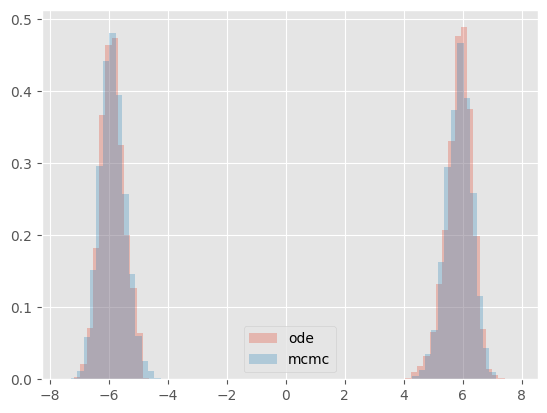

In [96]:
plt.hist(ode_samps4, label="ode", alpha=0.3, density=True, bins=70);
plt.hist(np.hstack(mcmc_samps4), label="mcmc", alpha=0.3, density=True, bins=70);
plt.legend()

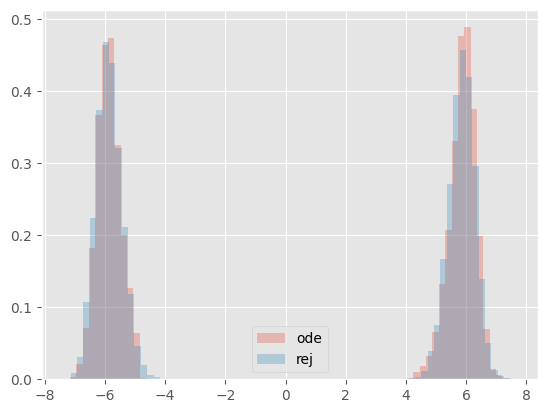

In [97]:
plt.hist(ode_samps4, label="ode", alpha=0.3, density=True, bins=70);
# plt.hist(np.hstack(mcmc_samps4), label="mcmc", alpha=0.3, density=True, bins=70);
plt.hist(rej_samps, label="rej", alpha=0.3, density=True, bins=70);
plt.legend()

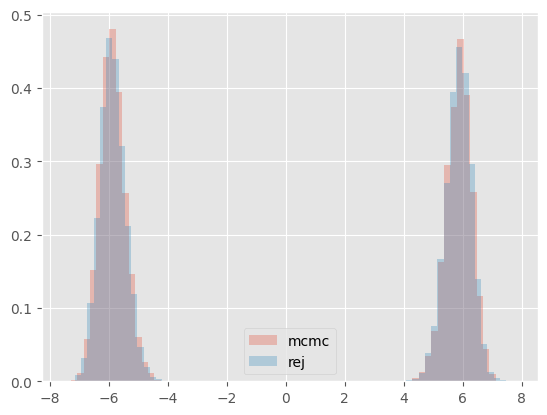

In [98]:
# plt.hist(ode_samps4, label="ode", alpha=0.3, density=True, bins=70);
plt.hist(np.hstack(mcmc_samps4), label="mcmc", alpha=0.3, density=True, bins=70);
plt.hist(rej_samps, label="rej", alpha=0.3, density=True, bins=70);
plt.legend()

In [170]:
wd(np.array(ode_samps4), rej_samps.squeeze(), p=2) / wd(us_base.squeeze(), rej_samps.squeeze(), p=2)

np.float64(0.06263820317115393)

In [159]:
wd(us_base.squeeze(), rej_samps.squeeze(), p=2)

np.float64(25.669467910531367)

In [167]:
wd(np.array(ode_samps4), rej_samps.squeeze(), p=2)

np.float64(1.6050963590470415)

In [168]:
wd(np.hstack(mcmc_samps4), rej_samps.squeeze(), p=2)

np.float64(1.0793946007654058)

In [169]:
wd(np.hstack(mcmc_samps4), rej_samps.squeeze(), p=2) / wd(us_base.squeeze(), rej_samps.squeeze(), p=2)

np.float64(0.04212291550192754)

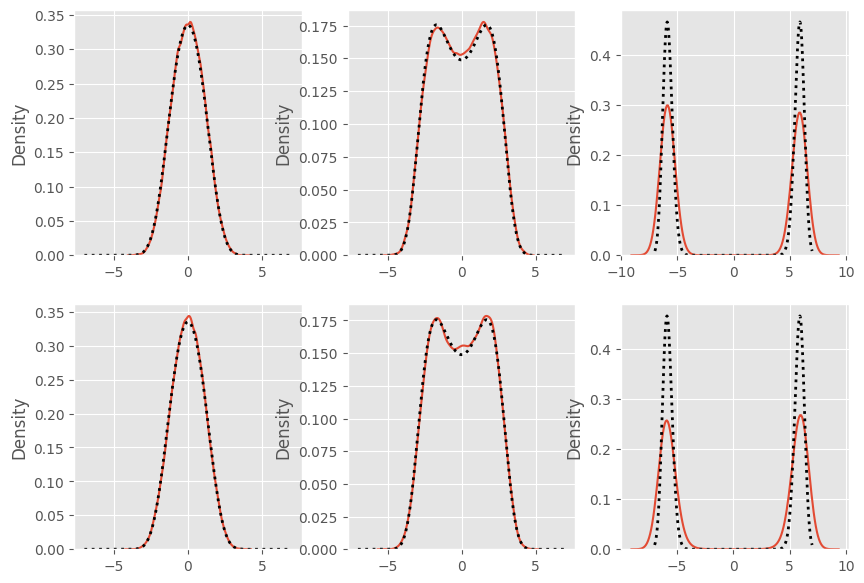

In [54]:
fig, axs = plt.subplots(2, 3, figsize=(10, 7))

kdeplot(mcmc_samps0, label="MCMC", ax=axs[0][0], bw_adjust=0.9)
axs[0][0].plot(grids[0], density_values[0], linestyle="dotted", linewidth=2, label="True", c="black")

kdeplot(ode_samps0, label="SI", ax=axs[1][0], bw_adjust=0.9)
axs[1][0].plot(grids[0], density_values[0], linestyle="dotted", linewidth=2, label="True", c="black")

kdeplot(mcmc_samps1, ax=axs[0][1], bw_adjust=0.9)
axs[0][1].plot(grids[1], density_values[1], linestyle="dotted", linewidth=2, c="black")

kdeplot(ode_samps1, ax=axs[1][1], bw_adjust=1.0)
axs[1][1].plot(grids[1], density_values[1], linestyle="dotted", linewidth=2, label="True", c="black")

kdeplot(np.hstack(mcmc_samps4), ax=axs[0][2], bw_adjust=0.9)
axs[0][2].plot(grids[2], density_values[2], linestyle="dotted", linewidth=2, c="black")

kdeplot(ode_samps4, ax=axs[1][2], bw_adjust=1.0)
axs[1][2].plot(grids[2], density_values[2], linestyle="dotted", linewidth=2, label="True", c="black")

<Axes: ylabel='Density'>

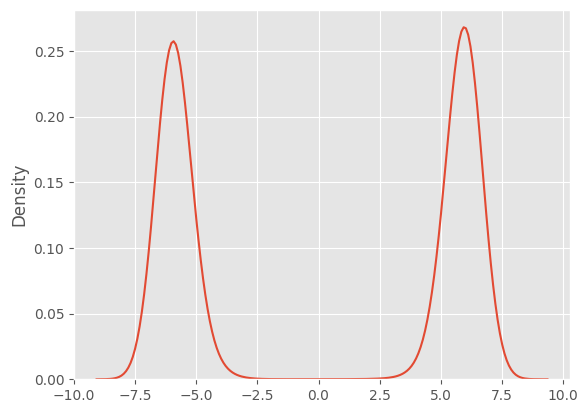

In [45]:
kdeplot(ode_samps4)

<Axes: ylabel='Density'>

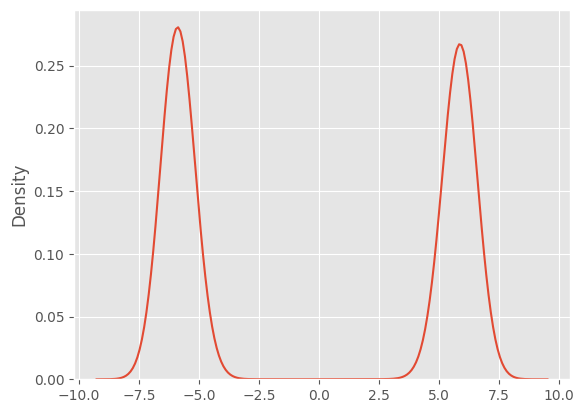

In [53]:
kdeplot(np.hstack(mcmc_samps4))